In [227]:
import pandas as pd
import numpy as np

In [228]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')

# Create a copy of the relevant columns to avoid SettingWithCopyWarning

data.head(10)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
0,818860012482918321,2025-01-01,146.71.50.198,1,2,False,1,1,1
1,818860012482918321,2025-01-01,149.36.49.225,28,2,False,1,1,1
2,818860012482918321,2025-01-01,162.142.125.242,3,2,False,1,1,1
3,818860012482918321,2025-01-01,162.142.125.247,2,2,False,1,1,1
4,818860012482918321,2025-01-01,162.142.125.255,3,2,False,1,1,1
5,818860012482918321,2025-01-01,185.230.63.171,6,2,False,1,1,1
6,818860012482918321,2025-01-01,23.26.221.12,49,2,False,1,1,1
7,818860012482918321,2025-01-01,23.26.221.2,51,2,False,1,1,1
8,818860012482918321,2025-01-01,23.26.221.4,36,2,False,1,1,1
9,818860012482918321,2025-01-01,34.160.111.145,4,2,False,1,1,1


In [229]:
# Ensure the 'date' column is in datetime format
data['date'] = pd.to_datetime(data['date'])

# Filter for the last 90 days
cutoff_date = pd.Timestamp.now() - pd.Timedelta(days=60)
filtered_records = data[data['date'] >= cutoff_date]

In [230]:
filtered_records

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
9062,818860012482918321,2025-02-16,146.71.50.198,0,6,True,16,2,0
9063,818860012482918321,2025-02-16,149.36.49.225,0,6,True,16,2,0
9064,818860012482918321,2025-02-16,162.142.125.242,2,6,True,16,2,1
9065,818860012482918321,2025-02-16,162.142.125.247,3,6,True,16,2,1
9066,818860012482918321,2025-02-16,162.142.125.255,3,6,True,16,2,1
...,...,...,...,...,...,...,...,...,...
20877,818860012482918321,2025-04-16,190.92.174.48,0,2,False,16,4,0
20878,818860012482918321,2025-04-16,190.92.174.92,0,2,False,16,4,0
20879,818860012482918321,2025-04-16,20.48.204.4,0,2,False,16,4,0
20880,818860012482918321,2025-04-16,47.237.115.193,0,2,False,16,4,0


In [231]:
# Set up lag features for 'seen'
for lag in [1, 3]:  # Use smaller lags
    filtered_records[f'seen_lag_{lag}'] = (
        filtered_records.groupby(['API_UserName', 'indicator'])['seen']
        .shift(lag)
    )

# Rolling features for 'observations'
filtered_records['obs_roll_3'] = (
    filtered_records.groupby(['API_UserName', 'indicator'])['observations']
    .transform(lambda x: x.shift(1).rolling(window=3).mean())
)

def dynamic_lookback(group, lookback_days=15):
    """
    Filters the group to include only rows within the look-back period.
    The look-back period starts from the last 'seen' event.
    If no 'seen' event exists, return the last `lookback_days` rows.
    """
    last_seen_date = group[group['seen'] == 1]['date'].max()
    if pd.isna(last_seen_date):
        # If no 'seen' event exists, return the last `lookback_days` rows
        return group.tail(lookback_days)
    cutoff_date = last_seen_date - pd.Timedelta(days=lookback_days)
    return group[group['date'] >= cutoff_date]

# Apply the dynamic look-back function
filtered_records = (
    filtered_records.groupby(['API_UserName', 'indicator'], group_keys=False)
    .apply(lambda group: dynamic_lookback(group, lookback_days=30))  # Adjust lookback_days as needed
)

# Update the global `data` variable with the filtered records
data = filtered_records.copy()

C:\Users\jaskew\AppData\Local\Temp\ipykernel_34044\1953066402.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_records[f'seen_lag_{lag}'] = (
C:\Users\jaskew\AppData\Local\Temp\ipykernel_34044\1953066402.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_records[f'seen_lag_{lag}'] = (
C:\Users\jaskew\AppData\Local\Temp\ipykernel_34044\1953066402.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

In [232]:
data.head(40)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen,seen_lag_1,seen_lag_3,obs_roll_3
11193,818860012482918321,2025-02-26,102.129.153.158,0,2,False,26,2,0,0.0,0.0,0.000000
11390,818860012482918321,2025-02-27,102.129.153.158,0,3,False,27,2,0,0.0,0.0,0.000000
11587,818860012482918321,2025-02-28,102.129.153.158,0,4,False,28,2,0,0.0,0.0,0.000000
11784,818860012482918321,2025-03-01,102.129.153.158,0,5,True,1,3,0,0.0,0.0,0.000000
11981,818860012482918321,2025-03-02,102.129.153.158,0,6,True,2,3,0,0.0,0.0,0.000000
12178,818860012482918321,2025-03-03,102.129.153.158,0,0,False,3,3,0,0.0,0.0,0.000000
12375,818860012482918321,2025-03-04,102.129.153.158,0,1,False,4,3,0,0.0,0.0,0.000000
12572,818860012482918321,2025-03-05,102.129.153.158,0,2,False,5,3,0,0.0,0.0,0.000000
12769,818860012482918321,2025-03-06,102.129.153.158,0,3,False,6,3,0,0.0,0.0,0.000000
12966,818860012482918321,2025-03-07,102.129.153.158,4,4,False,7,3,1,0.0,0.0,0.000000


In [233]:
# Shift the 'seen' column to create the 7-day-ahead target
data['seen_in_7_days'] = data.groupby(['API_UserName', 'indicator'])['seen'].shift(-7)

# Drop rows with NaN in target or features (common after shifting/rolling)
model_data = data.dropna(subset=[
    'seen_lag_1', 'seen_lag_3',
    'obs_roll_3', 'seen_in_7_days'
]).copy()  # Explicitly create a copy

# Make sure the target is binary (sometimes booleans get turned into floats)
model_data['seen_in_7_days'] = model_data['seen_in_7_days'].astype(int)
indicators = model_data['indicator']  # Retain the 'indicator' column
model_data.head(10)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen,seen_lag_1,seen_lag_3,obs_roll_3,seen_in_7_days
11193,818860012482918321,2025-02-26,102.129.153.158,0,2,False,26,2,0,0.0,0.0,0.0,0
11390,818860012482918321,2025-02-27,102.129.153.158,0,3,False,27,2,0,0.0,0.0,0.0,0
11587,818860012482918321,2025-02-28,102.129.153.158,0,4,False,28,2,0,0.0,0.0,0.0,1
11784,818860012482918321,2025-03-01,102.129.153.158,0,5,True,1,3,0,0.0,0.0,0.0,0
11981,818860012482918321,2025-03-02,102.129.153.158,0,6,True,2,3,0,0.0,0.0,0.0,0
12178,818860012482918321,2025-03-03,102.129.153.158,0,0,False,3,3,0,0.0,0.0,0.0,0
12375,818860012482918321,2025-03-04,102.129.153.158,0,1,False,4,3,0,0.0,0.0,0.0,0
12572,818860012482918321,2025-03-05,102.129.153.158,0,2,False,5,3,0,0.0,0.0,0.0,0
12769,818860012482918321,2025-03-06,102.129.153.158,0,3,False,6,3,0,0.0,0.0,0.0,0
12966,818860012482918321,2025-03-07,102.129.153.158,4,4,False,7,3,1,0.0,0.0,0.0,0


In [234]:
model_data['seen_in_7_days'].value_counts()

seen_in_7_days
0    6408
1     756
Name: count, dtype: int64

In [235]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# Define features and target
X = model_data[['seen', 'seen_lag_1', 'seen_lag_3', 'obs_roll_3', 'dayofweek', 'is_weekend', 'month', 'observations']]
y = model_data['seen_in_7_days']
indicators = model_data['indicator']  # Retain the 'indicator' column

# Step 1: Split the data
X_train, X_test, y_train, y_test, indicators_train, indicators_test = train_test_split(
    X, y, indicators, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Balance the training data using SMOTE
smote = SMOTE(random_state=42, k_neighbors=min(5, y_train.value_counts().min() - 1))
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Apply PCA to the balanced data
# Use the scaled training data directly for logistic regression
X_train_pca_balanced = X_train_balanced
# Step 6: Train the logistic regression model
log_reg = LogisticRegression(max_iter=1000, random_state=123, solver='liblinear')
log_reg.fit(X_train_pca_balanced, y_train_balanced)

# Step 7: Generate predictions for the test set
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Step 8: Create the results DataFrame
results = pd.DataFrame({
    'Indicator': indicators_test.reset_index(drop=True),
    'Probability_Seen_in_7_Days': y_pred_proba
})

# Display the top 10 highest results
print(results.sort_values(by='Probability_Seen_in_7_Days', ascending=False).head(10))

          Indicator  Probability_Seen_in_7_Days
653  162.241.248.14                         1.0
649    104.21.61.32                         1.0
645    23.26.221.27                         1.0
720    23.26.221.17                         1.0
605  34.160.111.145                         1.0
633    23.26.221.20                         1.0
319    23.26.221.17                         1.0
318    104.21.61.32                         1.0
792    23.26.221.20                         1.0
384   68.67.179.164                         1.0


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


<Figure size 800x600 with 0 Axes>

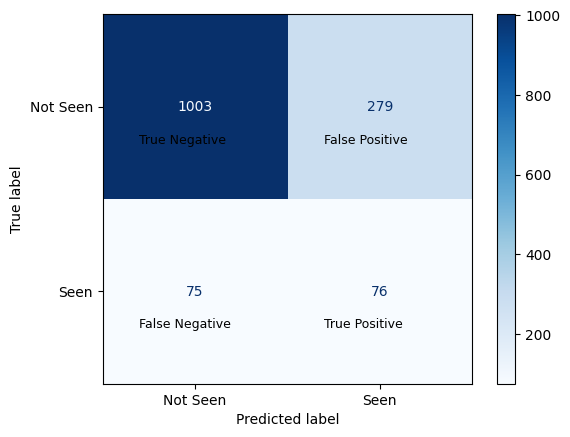

In [236]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt  # Ensure matplotlib is imported for plotting

# Generate predictions using the PCA-transformed test data
y_pred = log_reg.predict(X_test)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Define the actual class labels
class_labels = ['Not Seen', 'Seen']

# Create a ConfusionMatrixDisplay object for visualization
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix, 
    display_labels=class_labels  # Use actual class labels
)

# Plot the confusion matrix with a blue color map for better readability
plt.figure(figsize=(8, 6))  # Adjust the figure size for better visualization
disp.plot(cmap='Blues', values_format='d')  # Use 'd' to display integer values

# Add labels for True Positive, False Positive, True Negative, and False Negative
plt.text(-0.3, 0.2, 'True Negative', fontsize=9, color='black', ha='left')
plt.text(0.7, 0.2, 'False Positive', fontsize=9, color='black', ha='left')
plt.text(-0.3, 1.2, 'False Negative', fontsize=9, color='black', ha='left')
plt.text(0.7, 1.2, 'True Positive', fontsize=9, color='black', ha='left')

# Ensure numbers in the confusion matrix are not displayed in scientific notation
np.set_printoptions(suppress=True)

# Show the plot
plt.show()

In [237]:
from sklearn.metrics import average_precision_score

# Ensure X_test is transformed using PCA
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"Precision-Recall AUC: {pr_auc:.2f}")

Precision-Recall AUC: 0.27


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [238]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(log_reg, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')

# Print the cross-validation scores and their mean
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

Cross-validation scores: [0.69185763 0.68015602 0.7        0.68341463 0.69560976]
Mean cross-validation score: 0.690207608424207


In [239]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [240]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Ensure X_test_pca and y_test have the same number of samples
X_test_pca = X_test.iloc[:len(y_test)]

# Make predictions using the Random Forest model
y_pred_rf = rf.predict(X_test_pca)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Print the evaluation metrics
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print(f"Random Forest Precision: {precision_rf:.2f}")
print(f"Random Forest Recall: {recall_rf:.2f}")
print(f"Random Forest F1 Score: {f1_rf:.2f}")

# Print the classification report
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.63
Random Forest Precision: 0.17
Random Forest Recall: 0.68
Random Forest F1 Score: 0.28

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.62      0.75      1282
           1       0.17      0.68      0.28       151

    accuracy                           0.63      1433
   macro avg       0.56      0.65      0.51      1433
weighted avg       0.86      0.63      0.70      1433



C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [241]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42, scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]))
xgb.fit(X_train_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [242]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions using the XGBoost model
y_pred_xgb = xgb.predict(X_test)

# Calculate evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Print the evaluation metrics
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}")
print(f"XGBoost Precision: {precision_xgb:.2f}")
print(f"XGBoost Recall: {recall_xgb:.2f}")
print(f"XGBoost F1 Score: {f1_xgb:.2f}")

# Print the classification report
print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.11
XGBoost Precision: 0.11
XGBoost Recall: 1.00
XGBoost F1 Score: 0.19

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1282
           1       0.11      1.00      0.19       151

    accuracy                           0.11      1433
   macro avg       0.05      0.50      0.10      1433
weighted avg       0.01      0.11      0.02      1433



C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()